# 05 · Stack, calibrate, report and submit

Level-2 model on the level-1 OOF predictions of notebooks 04 and 06.

**What the leaderboard taught us (and how it is used here)**

| run | change | CV (true metric) | public LB |
|---|---|---|---|
| 1 | audio only, 3-model NNLS | 0.409 | 0.3958 |
| 2 | + transcripts / LLM, stack on crop OOF | 0.384 | 0.3800 (0.3752 with speaker smoothing) |
| 3 | + population weights / calibration, adapters, more text views | 0.375 | 0.3895 (0.3786 with speaker prior ≥ 0.93) |
| 4 | speaker+prompt folds, crops for every head, no population terms | 0.372 | 0.3752 → 0.3660 smoothed → 0.3621 + prior |
| 5 | **this notebook**: + frozen RoBERTa / ELECTRA / DeBERTa text encoders | 0.368 | 0.3693 → 0.3593 smoothed → **0.3549** + prior |
| final | score-aware blend of 26 scored submissions + smoothing (notebook 07) | — | **0.3262** |

1. **Metric** = 0.6·RMSE + 0.4·(1 − Pearson), identified from 5 diagnostic submissions (run-3 predictions shifted by 0, −0.5, −1, −1.5 and shrunk 2× around their mean). It fits to 0.0003; the commonly assumed (RMSE + 1 − r)/2 misfits by 0.033. Under the true metric the CV↔LB gap is small (−0.013, −0.004, +0.015).
2. **Prompt shift:** "free time / family" answers are 43% of test but 3% of train, and "floods" 10% vs 1%. Folds hold out speakers **and** prompts, so the NNLS weights reflect how each view transfers to unseen prompts. LLM views lose 0.03–0.07 on unseen prompts; audio views lose < 0.01.
3. **No population weights or calibration**: they caused run 3's regression.
4. **NNLS** (weights ≥ 0) with nested CV, pruning, and a single least-squares calibration (RMSE-optimal; Pearson is affine-invariant).
5. **Transductive post-processing, both validated on the LB:** speaker smoothing within tight test clusters (−0.005 in run 2), and a speaker-label prior for test clips whose voice matches a train clip at cosine ≥ 0.93 (−0.011 in run 3; the looser 0.90 variant hurt, +0.013).

The **training RMSE** required by the brief is reported in §5.

In [1]:
import os, sys, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
for p in Path("/kaggle/input").glob("*/src"):
    sys.path.insert(0, str(p))
os.environ.setdefault("SHL_DATA", str(ROOT / "shl-hiring-assessment-2026"))
from shl import data, folds as F, metrics, stack

OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else ROOT / "artifacts"
PRED = OUT / "preds"
sns.set_theme(style="whitegrid")
meta = pd.read_csv(OUT / "meta.csv")
fold_df = pd.read_csv(OUT / "folds_joint.csv"); folds = fold_df.drop(columns="uid")
row_of = {u: i for i, u in enumerate(meta.uid)}
fit_rows = np.array([row_of[u] for u in fold_df.uid])
test_rows = np.where(meta.split == "test")[0]
y = meta.label.values[fit_rows]

files = sorted(PRED.glob("*.npz"))
names = [f.stem for f in files]
L = [np.load(f) for f in files]
P_full = np.column_stack([l["oof"] for l in L])           # OOF on held-out full clips
P_short = np.column_stack([l["oof_short"] for l in L])    # OOF on 40-50 s crops of held-out clips
T = np.column_stack([l["test"] for l in L])
I = np.column_stack([l["insample"] for l in L])
print(f"{len(names)} level-1 models:", names)

21 level-1 models: ['hubert_large_adapter__mlp', 'hubert_large_B__ridge', 'text_enc_deberta_ctc__ridge', 'text_enc_deberta_whisper__ridge', 'text_enc_electra_ctc__ridge', 'text_enc_electra_whisper__ridge', 'text_enc_roberta_ctc__ridge', 'text_enc_roberta_whisper__ridge', 'text_hand__lgbm', 'text_hand__svr', 'text_llm4bctc__ridge', 'text_llm__ridge', 'text_tfidf_ctc__ridge', 'w2vbert2_B__ridge', 'w2vbert2_B__svr', 'wavlm_large_A__ridge', 'wavlm_large_A__svr', 'wavlm_large_adapter__mlp', 'whisper_v3_A__ridge', 'whisper_v3_A__svr', 'whisper_v3_adapter__mlp']


## 1 · The prompt shift
Topic clusters of the transcripts (TF-IDF → SVD → k-means, unsupervised, train + test).

prompt,0,1,2,3,4,5,6,7,8,9,10,11
split,,,,,,,,,,,,
test,0.019,0.069,0.032,0.032,0.111,0.056,0.431,0.056,0.046,0.102,0.032,0.014
train,0.104,0.133,0.086,0.100,0.120,0.137,0.031,0.040,0.130,0.007,0.057,0.056


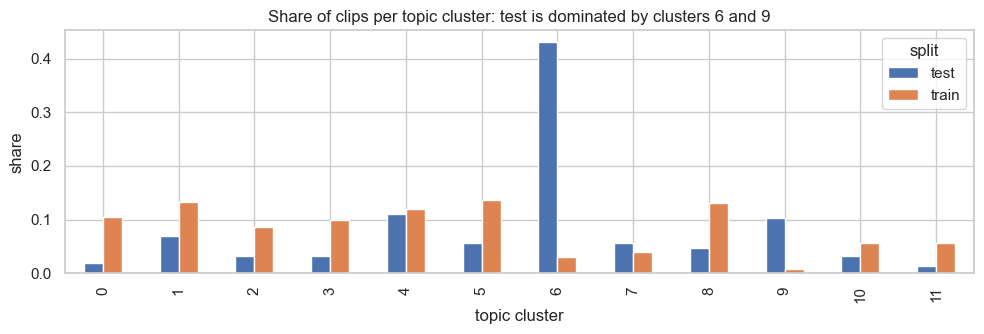

In [2]:
pc = pd.read_csv(OUT / "prompt_clusters.csv")
pc["split"] = pc.uid.str.split("/").str[0]
tab = pd.crosstab(pc.prompt, pc.split, normalize="columns").round(3)
display(tab.T)
fig, ax = plt.subplots(figsize=(10, 3.5))
tab.plot.bar(ax=ax); ax.set(title="Share of clips per topic cluster: test is dominated by clusters 6 and 9", xlabel="topic cluster", ylabel="share")
plt.tight_layout(); plt.show()

## 2 · Level-1 models

,name,rmse,pearson,composite_short,composite_full
20,whisper_v3_adapter__mlp,0.5647,0.8322,0.4059,0.4035
19,whisper_v3_A__svr,0.5818,0.8205,0.4209,0.4283
17,wavlm_large_adapter__mlp,0.5821,0.8205,0.4211,0.4178
18,whisper_v3_A__ridge,0.5878,0.8148,0.4268,0.4305
16,wavlm_large_A__svr,0.5929,0.8155,0.4295,0.4306
15,wavlm_large_A__ridge,0.5914,0.8128,0.4297,0.4275
0,hubert_large_adapter__mlp,0.6066,0.8021,0.4431,0.4424
1,hubert_large_B__ridge,0.6204,0.7914,0.4557,0.4655
5,text_enc_electra_whisper__ridge,0.6344,0.7813,0.4681,0.4519
4,text_enc_electra_ctc__ridge,0.6351,0.7815,0.4684,0.4498


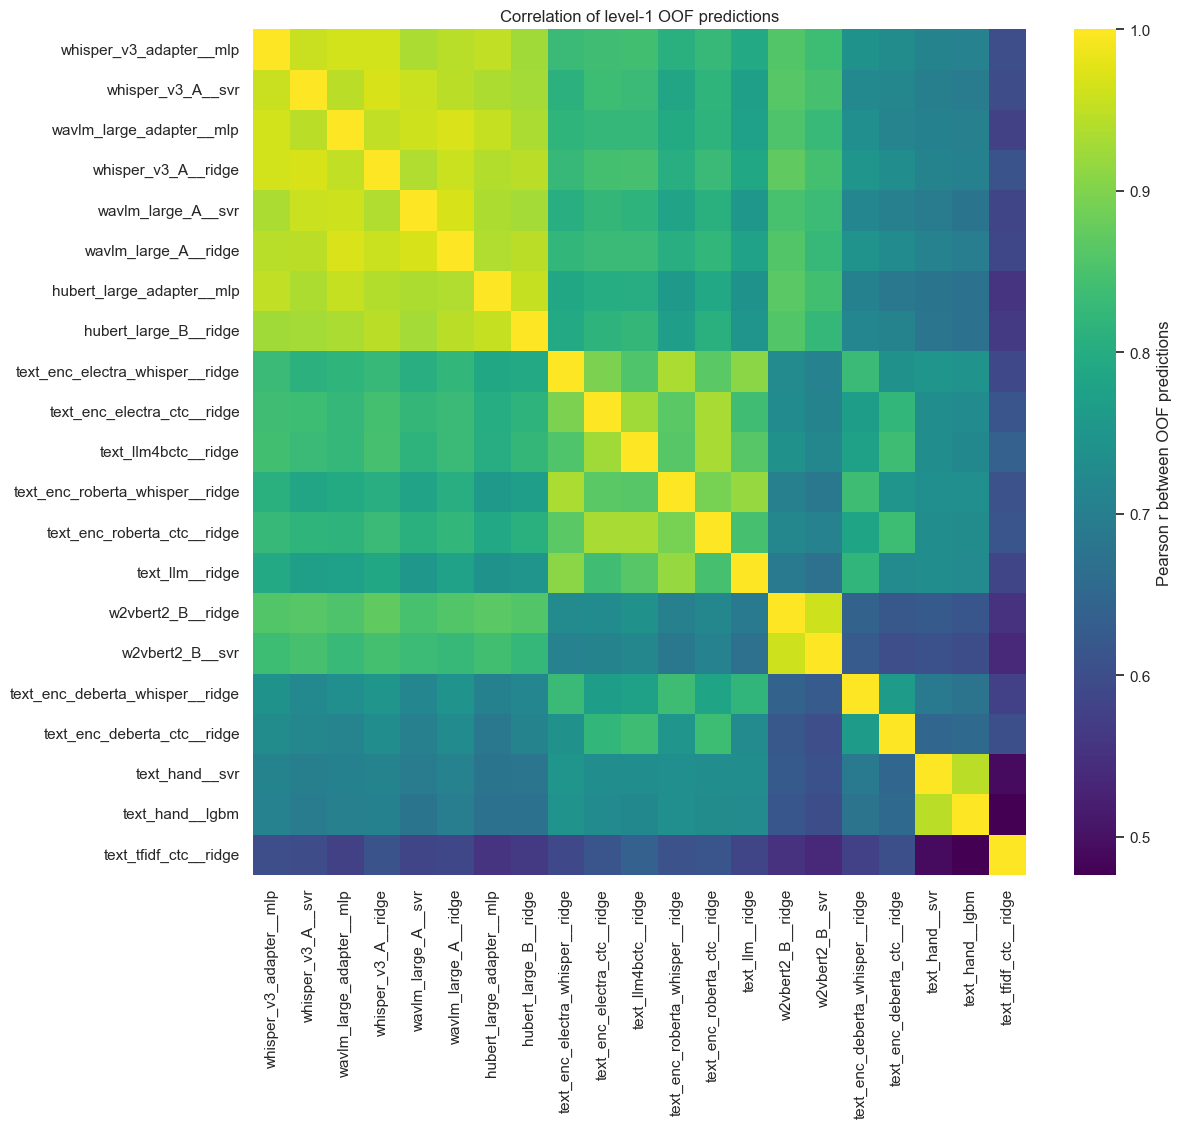

In [3]:
lvl1 = pd.DataFrame([{**metrics.report(y, P_short[:, j], n, ci=False),
                      "composite_full": metrics.composite(y, P_full[:, j])} for j, n in enumerate(names)]).sort_values("composite")
display(lvl1[["name", "rmse", "pearson", "composite", "composite_full"]].rename(columns={"composite": "composite_short"}).round(4))
order = lvl1.name.tolist()
C = pd.DataFrame(P_short, columns=names)[order].corr()
fig, ax = plt.subplots(figsize=(0.45 * len(order) + 3, 0.45 * len(order) + 2))
sns.heatmap(C, cmap="viridis", vmin=C.values.min(), vmax=1, ax=ax, cbar_kws={"label": "Pearson r between OOF predictions"})
ax.set_title("Correlation of level-1 OOF predictions"); plt.tight_layout(); plt.show()

## 3 · Stacking with nested CV, and pruning
Stacks are fitted on crop OOF (test-like length) and on full-clip OOF. The better nested score is used.

In [4]:
variants, candidates = {}, {}
for tag, P in (("short", P_short), ("full", P_full)):
    allm = stack.nested_stack(P, y, folds)
    kept = stack.greedy_prune(P, y, folds, names, max_models=12)
    ki = [names.index(k) for k in kept]
    pr = stack.nested_stack(P[:, ki], y, folds)
    variants[f"NNLS all {len(names)} ({tag} OOF)"] = allm["oof"]
    variants[f"NNLS pruned {len(kept)} ({tag} OOF)"] = pr["oof"]
    candidates[tag] = (pr["composite"], kept, ki, pr, P)
best1 = lvl1.iloc[0]["name"]
variants[f"best single ({best1}, short)"] = P_short[:, names.index(best1)]
compare = pd.DataFrame([{"model": k, **metrics.report(y, v, ci=True)} for k, v in variants.items()]).drop(columns="name").sort_values("composite")
display(compare.round(4))
TAG = min(candidates, key=lambda t: candidates[t][0])
_, kept, ki, pruned, P = candidates[TAG]
print(f"stack on {TAG} OOF; kept {len(kept)}: {kept}")
print("composite per fold seed:", np.round(pruned["composite_per_seed"], 4))

,model,rmse,pearson,composite,ci_low,ci_high
3,NNLS pruned 5 (full OOF),0.5196,0.8589,0.3682,0.3448,0.3903
1,NNLS pruned 5 (short OOF),0.5258,0.8551,0.3735,0.3489,0.3965
2,NNLS all 21 (full OOF),0.5262,0.8549,0.3738,0.3496,0.3963
0,NNLS all 21 (short OOF),0.5320,0.8514,0.3786,0.3543,0.4015
4,"best single (whisper_v3_adapter__mlp, short)",0.5647,0.8322,0.4059,0.3787,0.4332


stack on full OOF; kept 5: ['text_enc_roberta_whisper__ridge', 'text_llm__ridge', 'w2vbert2_B__ridge', 'wavlm_large_A__svr', 'whisper_v3_adapter__mlp']
composite per fold seed: [0.3672 0.3688 0.3666 0.3678 0.3724]


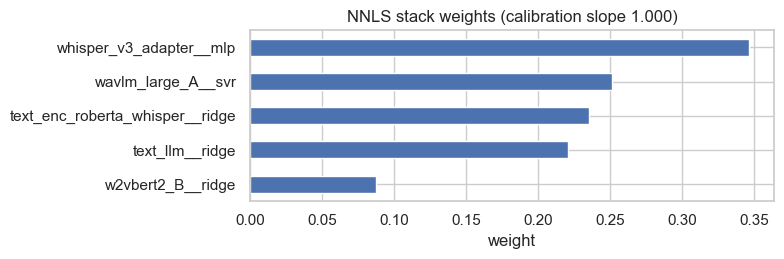

In [5]:
final = stack.fit_stack(P[:, ki], y, kept)
fig, ax = plt.subplots(figsize=(8, 0.35 * len(kept) + 1))
final["weights"].sort_values().plot.barh(ax=ax, color="#4c72b0")
ax.set(title=f"NNLS stack weights (calibration slope {final['beta'][0]:.3f})", xlabel="weight")
plt.tight_layout(); plt.show()

## 4 · Error analysis on OOF predictions

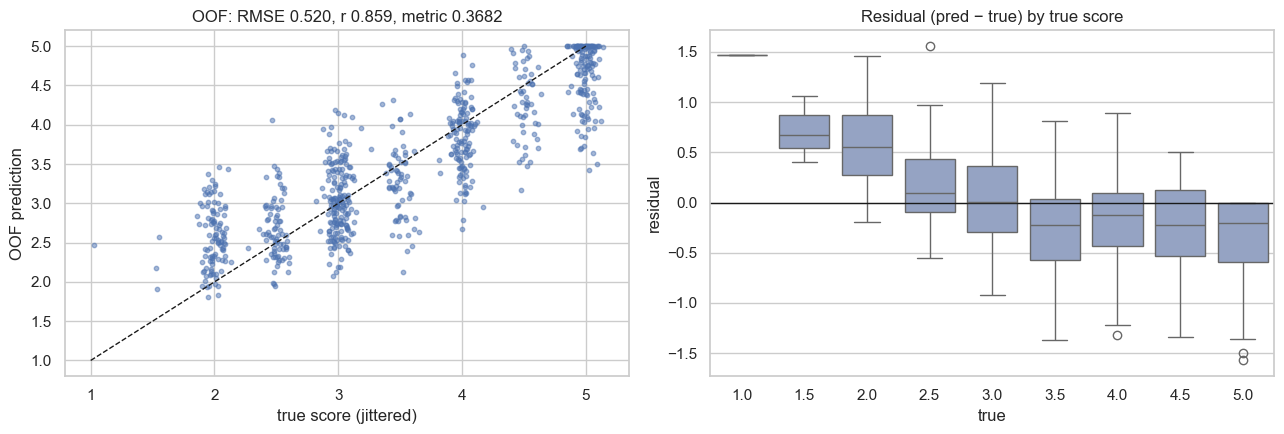

,topic cluster,n,rmse,r,bias
0,0,76,0.630,0.814,0.064
1,1,97,0.537,0.831,-0.140
2,2,63,0.555,0.787,-0.056
3,3,73,0.471,0.876,-0.021
4,4,88,0.471,0.906,-0.023
5,5,100,0.534,0.828,-0.011
6,6,23,0.579,0.859,-0.074
7,7,29,0.508,0.876,0.145
8,8,95,0.479,0.881,-0.021
9,9,5,0.601,0.823,0.420


In [6]:
oof = pruned["oof"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
jit = np.random.default_rng(0).normal(0, .06, len(y))
axes[0].scatter(y + jit, oof, s=10, alpha=.5); axes[0].plot([1, 5], [1, 5], "k--", lw=1)
axes[0].set(xlabel="true score (jittered)", ylabel="OOF prediction",
            title=f"OOF: RMSE {metrics.rmse(y, oof):.3f}, r {metrics.pearson(y, oof):.3f}, metric {metrics.composite(y, oof):.4f}")
res = pd.DataFrame({"true": y, "residual": oof - y})
sns.boxplot(data=res, x="true", y="residual", ax=axes[1], color="#8da0cb")
axes[1].axhline(0, c="k", lw=1); axes[1].set(title="Residual (pred − true) by true score")
plt.tight_layout(); plt.show()
prm = pc.set_index("uid").prompt.loc[fold_df.uid].values
per_prompt = pd.DataFrame([{"topic cluster": k, "n": int((prm == k).sum()), "rmse": metrics.rmse(y[prm == k], oof[prm == k]),
                            "r": metrics.pearson(y[prm == k], oof[prm == k]), "bias": (oof - y)[prm == k].mean()}
                           for k in np.unique(prm) if (prm == k).sum() >= 5])
display(per_prompt.round(3))

## 5 · Post-processing, training RMSE and submissions

In [7]:
spk = np.load(OUT / "speaker_emb.npy")
center = spk[fit_rows].mean(0)
Z_fit, Z_test = F.prepare_embeddings(spk[fit_rows], center), F.prepare_embeddings(spk[test_rows], center)
# speaker smoothing within tight test clusters (validated on LB in run 2)
sim = stack.simulate_cluster_smoothing(oof, y, F.cluster_speakers(Z_fit, 0.10))
LAM = float(sim.loc[sim.composite.idxmin(), "lambda"])
print(f"smoothing: simulated best lambda {LAM}, gain {sim.composite.iloc[0] - sim.composite.min():.4f}")
LAM = min(max(LAM, 0.2), 0.4)    # LB-validated range (run 2 used 0.3)
# speaker-label prior at cosine >= 0.93 (validated on LB in run 3; 0.90 hurt)
S_tt = Z_test @ Z_fit.T
test_sim, test_nn_label = S_tt.max(1), y[S_tt.argmax(1)]
print(f"speaker prior affects {(test_sim > 0.93).sum()} test clips")

base = stack.apply_stack(final, T[:, ki])
smooth = stack.cluster_smooth(base, F.cluster_speakers(Z_test, 0.10), LAM)
smooth_prior = stack.speaker_label_prior(smooth, test_sim, test_nn_label, 0.93, 0.5)
gate = meta.gate.values[test_rows].astype(bool)
for v in (base, smooth, smooth_prior):
    v[gate] = 0.0

train_insample = stack.apply_stack(final, I[:, ki])
summary = pd.DataFrame([
    {"set": "train (in-sample, required)", "rmse": metrics.rmse(y, train_insample), "pearson": metrics.pearson(y, train_insample),
     "metric": metrics.composite(y, train_insample)},
    {"set": "train OOF, speaker+prompt held out (honest)", "rmse": metrics.rmse(y, oof), "pearson": metrics.pearson(y, oof),
     "metric": metrics.composite(y, oof)},
])
display(summary.round(4))

DATA = data.find_data_dir()
outs = {"run5_model_only": base, "run5_smooth": smooth, "run5_smooth_prior": smooth_prior}
for tag, pred in outs.items():
    sub = data.submission_frame(DATA, meta.file.values[test_rows], pred)
    assert len(sub) == 216 and sub.iloc[:, 1].between(0, 5).all() and sub.iloc[:, 0].is_unique
    sub.to_csv(OUT / f"{tag}.csv", index=False)
    print(f"{tag}.csv: mean {pred.mean():.3f}, sd {pred.std():.3f}")
pd.read_csv(OUT / "run5_smooth_prior.csv").to_csv(OUT / "submission_run5.csv", index=False)
print("best single model: run5_smooth_prior.csv (LB 0.3549); final submission = notebook 07 blend (LB 0.3262)")

smoothing: simulated best lambda 0.30000000000000004, gain 0.0037
speaker prior affects 19 test clips


,set,rmse,pearson,metric
0,"train (in-sample, required)",0.3225,0.9489,0.2139
1,"train OOF, speaker+prompt held out (honest)",0.5196,0.8589,0.3682


run5_model_only.csv: mean 3.296, sd 0.860
run5_smooth.csv: mean 3.296, sd 0.848
run5_smooth_prior.csv: mean 3.308, sd 0.850
best single model: run5_smooth_prior.csv (LB 0.3549); final submission = notebook 07 blend (LB 0.3262)


In [8]:
log = OUT / "experiments.csv"
prev = pd.read_csv(log) if log.exists() else pd.DataFrame()
row = pd.DataFrame([{"time": datetime.datetime.now().isoformat(timespec="minutes"), "n_models": len(kept), "models": ";".join(kept),
                     "smoothing": True, "label_prior": True, "cv_rmse": metrics.rmse(y, oof), "cv_pearson": metrics.pearson(y, oof),
                     "cv_composite": metrics.composite_5050(y, oof), "cv_true_metric": metrics.composite(y, oof),
                     "train_rmse_insample": metrics.rmse(y, train_insample), "public_lb": None,
                     "note": f"run5 re-run (report): stack on {TAG} OOF"}])
pd.concat([prev, row], ignore_index=True).to_csv(log, index=False)
pd.read_csv(log)[["time", "cv_true_metric", "public_lb", "note"]].tail()

C:\Users\Tanmay\AppData\Local\Temp\ipykernel_9780\3355248737.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([prev, row], ignore_index=True).to_csv(log, index=False)


,time,cv_true_metric,public_lb,note
2,2026-10-07T02:12,0.374482,0.3895,run3: pop-aware; LB B 0.3895 / C(prior .93) 0....
3,2026-10-07T19:19,0.371515,0.3621,"run4: speaker+prompt folds, crops everywhere, ..."
4,2026-10-07T19:47,0.368193,0.3549,"run4: speaker+prompt folds, crops everywhere, ..."
5,2026-10-07T20:50,NaN,0.3262,blend_v4_smooth 0.3262 (no smoothing 0.3308); ...
6,2026-10-07T20:53,0.368193,NaN,run5 re-run (report): stack on full OOF
